In [1]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# ours
S_MCMC=0.133
dS_MCMC_u=0.034
dS_MCMC_d=0.045

HOf_MCMC=2.813
dHOf_MCMC_u=0.250
dHOf_MCMC_d=0.258

exp_mu=182.937
dexp_mu_u=43.943
dexp_mu_d=42.032

sigma_host=0.605
dsigma_host_u=0.173
dsigma_host_d=0.134

# Macquart z>=0.25
F_Mac03=0.626
dF_Mac03_u=0.347
dF_Mac03_d=0.261

HOf_Mac03=3.272
dHOf_Mac03_u=0.469
dHOf_Mac03_d=0.434

# Macquart all data
F_Mac=0.650
dF_Mac_u=0.039
dF_Mac_d=0.075

HOf_Mac=2.770
dHOf_Mac_u=0.180
dHOf_Mac_d=0.196

In [3]:
def up_low_trans(func, median, dup, dlow):
    """
    Returns the upper and lower limits of a function evaluated at median, up, and low values.
    
    Parameters:
    func: callable
    median: array-like
    dup: array-like
    dlow: array-like, 
    
    Returns:
    tuple: (tr_median, tr_up_diff, tr_down_diff)
    """
    # input numpy arrays
    median = np.array(median)
    dup = np.array(dup)
    dlow = np.array(dlow)
    
    # calculate upper and lower limits
    up = median + dup
    if np.min(dup) < 0:
        print(f"Warning: dup {dup} is negative, using median + dup")
        
    if np.max(dlow)<=0:
        down = median + dlow
    else:
        down = median - dlow
    
    # calculate transformed values
    tr_up = func(up)
    tr_down = func(down)
    tr_median = func(median)
    
    if tr_down> tr_up:
        tr_down, tr_up = tr_up, tr_down  # Ensure tr_down is less than tr_up
    
    return tr_median, tr_up - tr_median, tr_down - tr_median

$ F\sim k\widetilde{F} \sim k\sqrt{S} $ relation

In [4]:
path='./interpolation/095_C0mean.npz'
load_arrays=np.load(path)
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

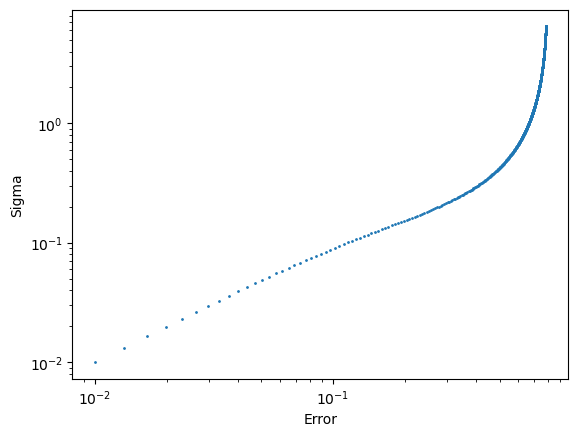

In [5]:
plt.scatter(Errors, Sigmas, s=1)
plt.ylabel('Sigma')
plt.xlabel('Error')
plt.xscale('log')
plt.yscale('log')

0.06885182186659902
0.06519259629814908


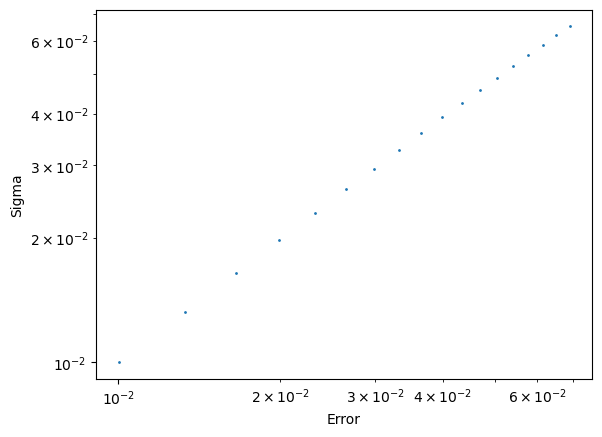

In [6]:
th=0.07
fit_error=Errors[Errors<=th]
fit_Sigmas=Sigmas[Errors<=th]
print(max(fit_error))
print(max(fit_Sigmas))
plt.scatter(fit_error, fit_Sigmas, s=1)
plt.ylabel('Sigma')
plt.xlabel('Error')
plt.xscale('log')
plt.yscale('log')

In [7]:
log_errors=np.log10(fit_error)
log_Sigmas=np.log10(fit_Sigmas)

def fit_fun(x, b):
    return x+b

popt, pcov = curve_fit(fit_fun, log_errors, log_Sigmas)
print(popt)
b=popt[0]
k=10**b
print(k)

[-0.00928051]
0.9788575323554154


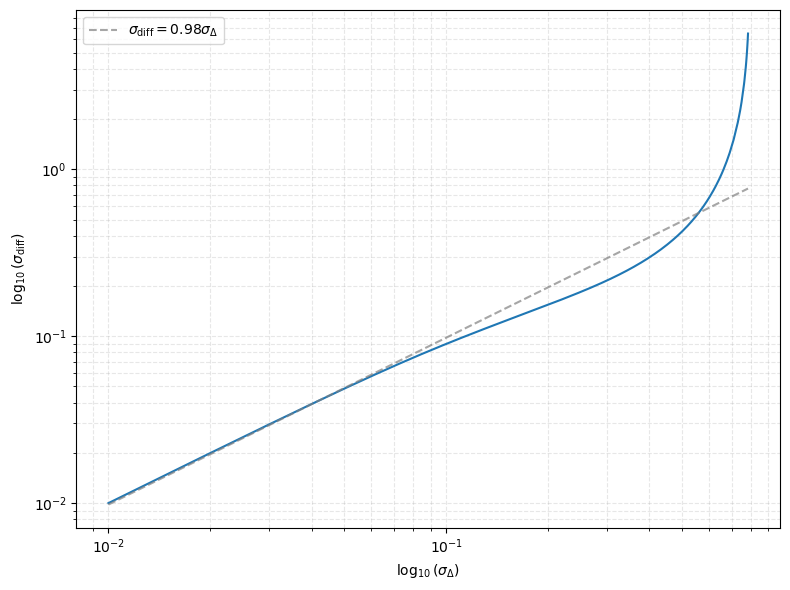

In [8]:
plt.figure(figsize=(8, 6))
# plt.scatter(Errors, Sigmas,s=0.5)
plt.plot(Errors, Sigmas)
plt.ylabel(r'$\log_{10} (\sigma_{\rm diff})$')
plt.xlabel(r'$\log_{10} (\sigma_\Delta)$')
plt.xscale('log',base=10)
plt.yscale('log',base=10)

x_min = min(Errors)
x_max = max(Errors)
x_range = np.logspace(np.log10(x_min), np.log10(x_max), 100)

y_ref = x_range * k
plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=r'$\sigma_{\rm diff} ='+f' {k:.2f}'+r'\sigma_\Delta $')

""" constants = [b-1, b-0.5, b, b+0.5, b+1]
for c in constants:
    const=(10**c)
    y_ref = x_range * const  # y = x * 10^c
    plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=r'$\sigma_{\rm diff} ='+f' ({const:.2e})'+r'\sigma_\Delta $') """

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('./plot/sigma_diff_vs_sigma_delta.pdf', dpi=300)

In [9]:
def S_F(F, k=k):
    return (F/k)**2

def F_S(S, k=k):
    return k * (S**0.5)

In [10]:
F_MCMC=up_low_trans(F_S, S_MCMC, dS_MCMC_u, dS_MCMC_d)
print(f'Ours MCMC F: {F_MCMC[0]:.3f}, +{F_MCMC[1]:.3f}, {F_MCMC[2]:.3f}')

Ours MCMC F: 0.357, +0.043, -0.067


$\sigma_{\rm diff}\sim F/\sqrt{z}$ for linear region

In [11]:
z_cut=0.25
sigma_range=0.6

def z_range(F, sigma_range):
    a=F/sigma_range
    return a**2

print(z_range(F_MCMC[0], sigma_range))

0.3539876531397448


In [12]:
S_Mac=up_low_trans(S_F, F_Mac, dF_Mac_u, dF_Mac_d)
S_Mac03=up_low_trans(S_F, F_Mac03, dF_Mac03_u, dF_Mac03_d)
print(f'Macquart S: {S_Mac[0]:.3f}, +{S_Mac[1]:.3f}, {S_Mac[2]:.3f}')
print(f'Macquart03 S: {S_Mac03[0]:.3f}, +{S_Mac03[1]:.3f}, {S_Mac03[2]:.3f}')

Macquart S: 0.441, +0.055, -0.096
Macquart03 S: 0.409, +0.579, -0.270


$ H_0 $

In [13]:
print(HUBBLE)

67.66


In [14]:
ObH2=0.0224*100*100
f_diff=0.84

In [15]:
fid=ObH2/HUBBLE*f_diff
print(fid)

2.7809636417381016


In [16]:
def H0_HOf(HOf):
    return ObH2/(HOf/f_diff)

In [17]:
H_Mac=up_low_trans(H0_HOf, HOf_Mac, dHOf_Mac_u, dHOf_Mac_d)
H_Mac03=up_low_trans(H0_HOf, HOf_Mac03, dHOf_Mac03_u, dHOf_Mac03_d)
H_MCMC=up_low_trans(H0_HOf, HOf_MCMC, dHOf_MCMC_u, dHOf_MCMC_d)
print(f'Hubble constant Macquart: {H_Mac[0]:.3f}, +{H_Mac[1]:.3f}, {H_Mac[2]:.3f}')
print(f'Hubble constant Macquart03: {H_Mac03[0]:.3f}, +{H_Mac03[1]:.3f}, {H_Mac03[2]:.3f}')
print(f'Hubble constant ours MCMC: {H_MCMC[0]:.3f}, +{H_MCMC[1]:.3f}, {H_MCMC[2]:.3f}')

Hubble constant Macquart: 67.928, +5.172, -4.145
Hubble constant Macquart03: 57.506, +8.794, -7.209
Hubble constant ours MCMC: 66.889, +6.754, -5.459


Variance

In [18]:
def sqrtsigma(sigma):
    a=np.exp(sigma**2)
    return np.sqrt((a-1)*a)

def Std_lognormal(x):
    '''
    x[0]: exp^mu, median
    x[1]: sigma
    '''
    return x[0]*sqrtsigma(x[1])

In [19]:
print(Std_lognormal([exp_mu+dexp_mu_u, sigma_host+dsigma_host_u]))

280.04911589056366


In [20]:
std=up_low_trans(Std_lognormal, [exp_mu, sigma_host], [dexp_mu_u, dsigma_host_u], [dexp_mu_d, dsigma_host_d])
print(f'Standard deviation: {std[0]:.3f}, +{std[1]:.3f}, {std[2]:.3f}')

Standard deviation: 146.046, +134.003, -67.586
